In [1]:
import numpy as np

- layers.Conv2D(filters=16, kernel_size=3, strides=1, padding="same", activation='relu', input_shape=(height, width, 3))
- filters = 16 --> no. of filters
- each filter is applied on the image to learn feature 
- kernel_size = 3 means, each filter is a 3x3 matrix 
- strides = 1 means , filter moves 1 pixel at a time
- padding = "same" means, The output height and width remain the same as the input.
- padding = "valid" means, The output height and width are reduced by the kernel size i.e no padding is added to input image
- layers.MaxPooling2D(pool_size=2),
- pool_size = 2 means, 2x2 matrix is used to pool the image
- it reduces the spatial dimensions of the feature map
- max value is selected from the 2x2 matrix

- Deal with overfittng
- AlexNet
- VG6 29, 16

- Transfer Learning
- Embedding in Image
- Image similarity
- iNCEPTION/Google model

- Batch Normalization + Dropout
- L1/L2 regularization
- Early stopping

- Data piplines
- Data augmentation

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Import tensorflow and its modules
import tensorflow as tf
from tensorflow import keras # this allows <keras.> instead of <tf.keras.>
from tensorflow.keras import layers # this allows <layers.> instead of <tf.keras.layers.>
tf.keras.utils.set_random_seed(111) # set random seed

# To supress any warnings during the flow
import warnings
warnings.filterwarnings('ignore')

- Dropout can happen only in dense layer 
- Batch Normalization can happen in both convolution layer and Dense layer

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn jupyter tensorflow


     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     - -------------------------------------- 0.4/12.9 MB 12.8 MB/s eta 0:00:01
     -- ------------------------------------- 0.9/12.9 MB 10.9 MB/s eta 0:00:02
     ---- ----------------------------------- 1.5/12.9 MB 11.6 MB/s eta 0:00:01
     ------ --------------------------------- 2.0/12.9 MB 11.5 MB/s eta 0:00:01
     ------- -------------------------------- 2.5/12.9 MB 11.3 MB/s eta 0:00:01
     --------- ------------------------------ 2.9/12.9 MB 11.0 MB/s eta 0:00:01
     ---------- ----------------------------- 3.4/12.9 MB 11.4 MB/s eta 0:00:01
     ----------- ---------------------------- 3.9/12.9 MB 11.2 MB/s eta 0:00:01
     ------------- -------------------------- 4.4/12.9 MB 11.6 MB/s eta 0:00:01
     -------------- ------------------------- 4.8/12.9 MB 11.4 MB/s eta 0:00:01
     ---------------- ----------------------- 5.4/12.9 MB 11.4 MB/s eta 0:00:01
     ------------------ --------------------- 5.


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Early Stopping 
- If my validation loss stops improving for a certain number of epochs, I stop training to prevent overfitting
# ReduceLROnPlateau (lr = learning rate)
- If my validation loss stops improving(not decreasing)  for a certain number of epochs, I reduce the learning rate.

# Data Augmentation
- Generate different versions of same image and train on those versions
- Examples: rotation, scaling, flipping, cropping, color jittering, etc.
- Helps in reducing overfitting
- Increases the size of the dataset
- Improves the generalization of the model


# Transfer Learning

- 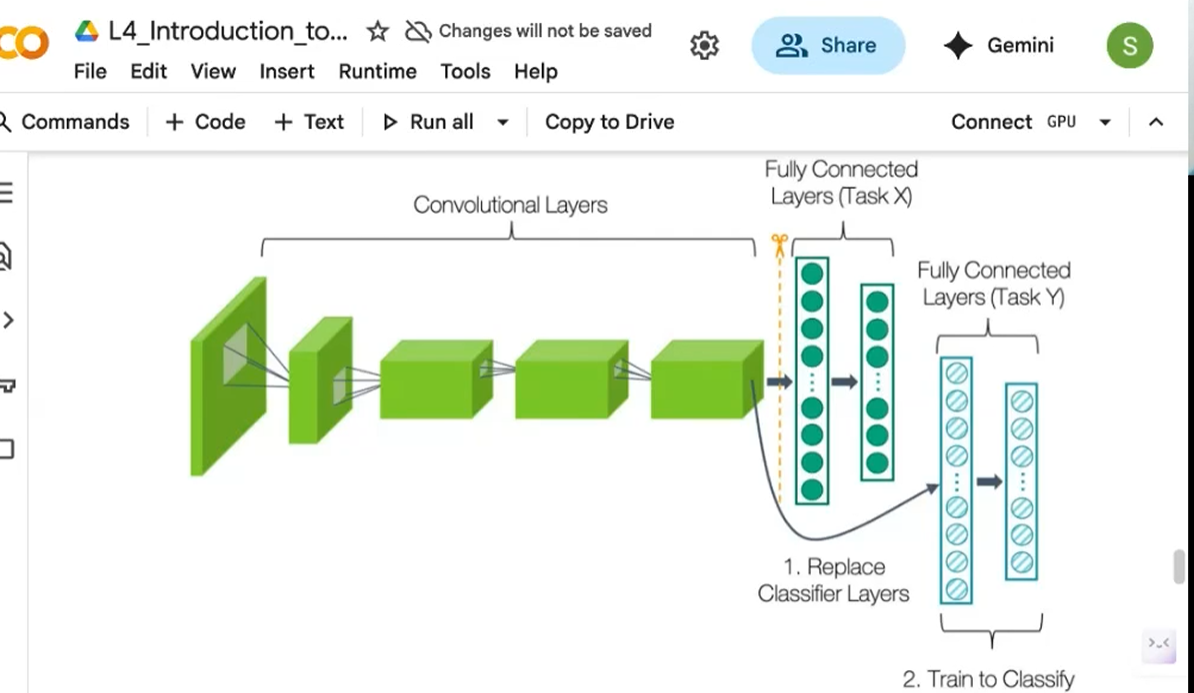
- If I already have a trained model for a similar task, I can use it as a starting point for my new task
- If my trained model has 1000 trained classes and I want to classify 10 classes, I can replace classifier layer with 10 classes.
- This only works if these 10 classes are a subset of 1000 classes

In [2]:
pretrained_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
pretrained_model.trainable = False

vgg16_model = tf.keras.Sequential([
    pretrained_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
